# 🧠 Naive Bayes Classification — Accident Dataset

**Mata Kuliah:** Machine Learning  
**Metode:** Naive Bayes Classifier dengan Laplace Smoothing  
**Dataset:** `accident.csv` (200 data)  
**Target:** `Survived` (1 = Selamat, 0 = Tidak Selamat)

---

### Fitur dalam Dataset
| Fitur | Tipe | Keterangan |
|---|---|---|
| Age | Numerik → Kategorikal | Usia korban |
| Gender | Kategorikal | Male / Female |
| Speed_of_Impact | Numerik → Kategorikal | Kecepatan saat tabrakan (km/h) |
| Helmet_Used | Kategorikal | Yes / No |
| Seatbelt_Used | Kategorikal | Yes / No |

## ⚙️ 0. Import Library & Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# Load dataset
df = pd.read_csv('accident.csv')

print(f"Shape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print()
df.head(10)

Shape  : (200, 6)
Kolom  : ['Age', 'Gender', 'Speed_of_Impact', 'Helmet_Used', 'Seatbelt_Used', 'Survived']



,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,Female,27,No,No,1
1,69,Female,46,No,Yes,1
2,46,Male,46,Yes,Yes,0
3,32,Male,117,No,Yes,0
4,60,Female,40,Yes,Yes,0
5,25,Male,49,Yes,Yes,1
6,38,Male,116,Yes,Yes,1
7,56,Male,47,Yes,Yes,1
8,36,Female,83,Yes,No,1
9,40,Female,116,Yes,No,1


## 📊 1. Eksplorasi Data (EDA)

In [19]:
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df.info()
print()
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()
print("=" * 50)
print("DISTRIBUSI KELAS (Survived)")
print("=" * 50)
print(df['Survived'].value_counts())
print()
df.describe()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              200 non-null    int64
 1   Gender           199 non-null    str  
 2   Speed_of_Impact  200 non-null    int64
 3   Helmet_Used      200 non-null    str  
 4   Seatbelt_Used    200 non-null    str  
 5   Survived         200 non-null    int64
dtypes: int64(3), str(3)
memory usage: 11.5 KB

MISSING VALUES
Age                0
Gender             1
Speed_of_Impact    0
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64

DISTRIBUSI KELAS (Survived)
Survived
1    101
0     99
Name: count, dtype: int64



,Age,Speed_of_Impact,Survived
count,200.00000,200.00000,200.00000
mean,43.42500,70.48500,0.50500
std,14.94191,30.01557,0.50123
min,18.00000,20.00000,0.00000
25%,31.00000,43.00000,0.00000
50%,43.50000,71.50000,1.00000
75%,56.00000,95.50000,1.00000
max,69.00000,119.00000,1.00000


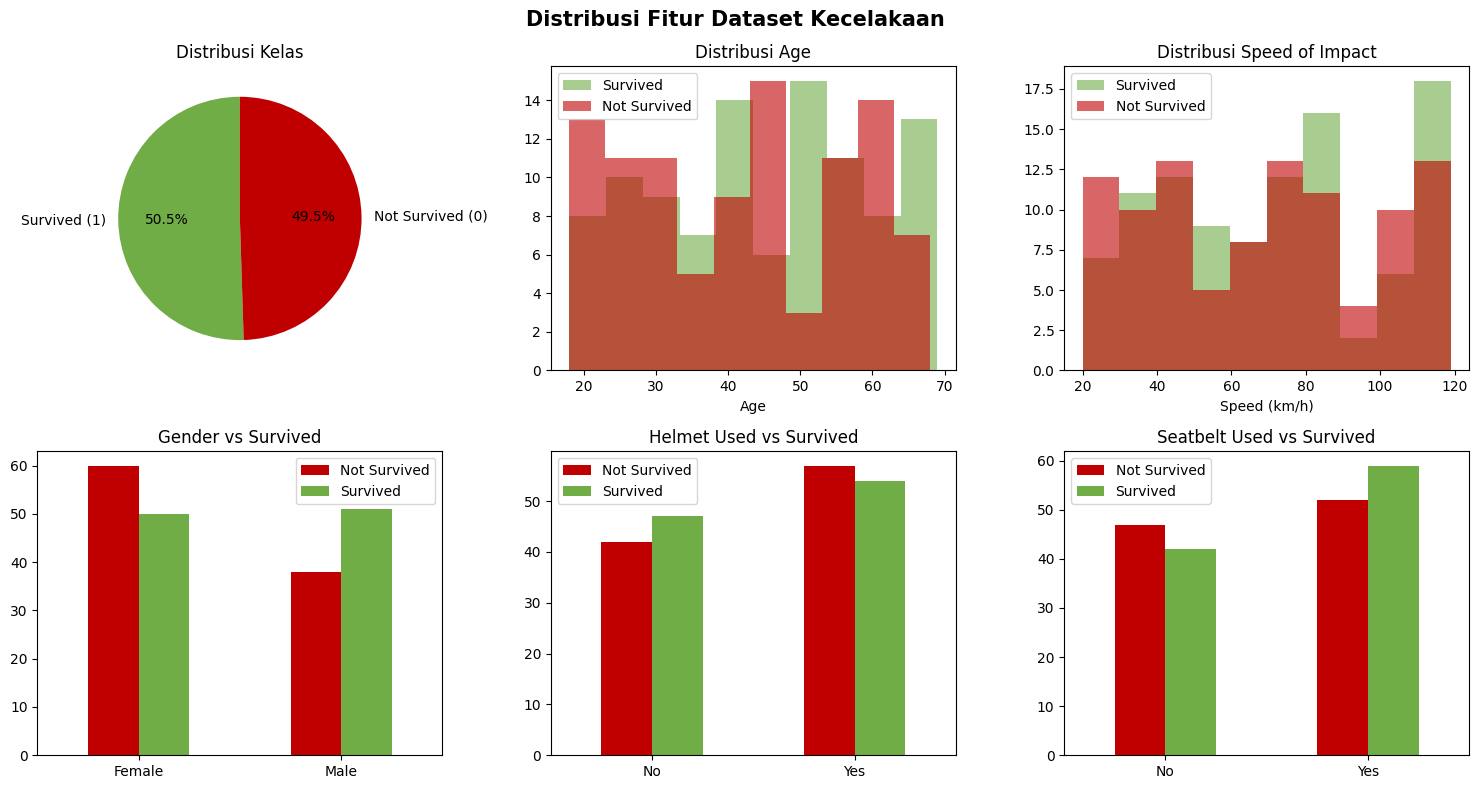

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Fitur Dataset Kecelakaan', fontsize=15, fontweight='bold')

colors = ['#2E75B6', '#C00000']

# Survived distribution
counts_surv = df['Survived'].value_counts()
axes[0,0].pie(counts_surv, labels=['Survived (1)', 'Not Survived (0)'],
              colors=['#70AD47','#C00000'], autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribusi Kelas')

# Age distribution
for cls, color, label in [(1,'#70AD47','Survived'),(0,'#C00000','Not Survived')]:
    axes[0,1].hist(df[df['Survived']==cls]['Age'], bins=10, alpha=0.6, color=color, label=label)
axes[0,1].set_title('Distribusi Age')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Speed distribution
for cls, color, label in [(1,'#70AD47','Survived'),(0,'#C00000','Not Survived')]:
    axes[0,2].hist(df[df['Survived']==cls]['Speed_of_Impact'], bins=10, alpha=0.6, color=color, label=label)
axes[0,2].set_title('Distribusi Speed of Impact')
axes[0,2].set_xlabel('Speed (km/h)')
axes[0,2].legend()

# Gender
gender_surv = df.groupby(['Gender','Survived']).size().unstack(fill_value=0)
gender_surv.plot(kind='bar', ax=axes[1,0], color=['#C00000','#70AD47'], rot=0)
axes[1,0].set_title('Gender vs Survived')
axes[1,0].set_xlabel('')
axes[1,0].legend(['Not Survived','Survived'])

# Helmet
helmet_surv = df.groupby(['Helmet_Used','Survived']).size().unstack(fill_value=0)
helmet_surv.plot(kind='bar', ax=axes[1,1], color=['#C00000','#70AD47'], rot=0)
axes[1,1].set_title('Helmet Used vs Survived')
axes[1,1].set_xlabel('')
axes[1,1].legend(['Not Survived','Survived'])

# Seatbelt
seat_surv = df.groupby(['Seatbelt_Used','Survived']).size().unstack(fill_value=0)
seat_surv.plot(kind='bar', ax=axes[1,2], color=['#C00000','#70AD47'], rot=0)
axes[1,2].set_title('Seatbelt Used vs Survived')
axes[1,2].set_xlabel('')
axes[1,2].legend(['Not Survived','Survived'])

plt.tight_layout()
plt.show()

## 🗂️ 2. Persiapan Data — Diskritisasi Fitur Numerik

Naive Bayes Kategorik memerlukan semua fitur dalam bentuk kategori.  
Fitur numerik `Age` dan `Speed_of_Impact` akan dibagi ke dalam *bins* (kelompok):

| Fitur | Bins | Label |
|---|---|---|
| Age | (0, 30], (30, 45], (45, 60], (60, 100] | Young, Middle, Senior, Old |
| Speed_of_Impact | (0, 50], (50, 80], (80, 120] | Low, Medium, High |

In [5]:
# Isi missing value dulu (jika ada)
for col in ['Gender', 'Helmet_Used', 'Seatbelt_Used']:
    df[col] = df[col].fillna('Unknown')

# Diskritisasi Age
df['Age_Cat'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31-45)', 'Senior (46-60)', 'Old (>60)']
)

# Diskritisasi Speed of Impact
df['Speed_Cat'] = pd.cut(
    df['Speed_of_Impact'],
    bins=[0, 50, 80, 120],
    labels=['Low (≤50)', 'Medium (51-80)', 'High (>80)']
)

print("Distribusi Age_Cat:")
print(df['Age_Cat'].value_counts().sort_index(), '\n')
print("Distribusi Speed_Cat:")
print(df['Speed_Cat'].value_counts().sort_index())

df[['Age','Age_Cat','Speed_of_Impact','Speed_Cat','Survived']].head(10)

Distribusi Age_Cat:
Age_Cat
Young (≤30)       48
Middle (31-45)    63
Senior (46-60)    55
Old (>60)         34
Name: count, dtype: int64 

Distribusi Speed_Cat:
Speed_Cat
Low (≤50)         65
Medium (51-80)    57
High (>80)        78
Name: count, dtype: int64


,Age,Age_Cat,Speed_of_Impact,Speed_Cat,Survived
0,56,Senior (46-60),27,Low (≤50),1
1,69,Old (>60),46,Low (≤50),1
2,46,Senior (46-60),46,Low (≤50),0
3,32,Middle (31-45),117,High (>80),0
4,60,Senior (46-60),40,Low (≤50),0
5,25,Young (≤30),49,Low (≤50),1
6,38,Middle (31-45),116,High (>80),1
7,56,Senior (46-60),47,Low (≤50),1
8,36,Middle (31-45),83,High (>80),1
9,40,Middle (31-45),116,High (>80),1


## 📐 3. Hitung Probabilitas Kelas (Prior Probability)

$$P(\text{Kelas}) = \frac{\text{Jumlah data kelas}}{\text{Total seluruh data}}$$

In [6]:
survived     = df[df['Survived'] == 1]
not_survived = df[df['Survived'] == 0]
n_yes   = len(survived)
n_no    = len(not_survived)
n_total = len(df)

p_yes = n_yes / n_total
p_no  = n_no  / n_total

print("=" * 50)
print("PROBABILITAS KELAS (Prior Probability)")
print("=" * 50)
print(f"Total Data         : {n_total}")
print(f"Survived (1)       : {n_yes}")
print(f"Not Survived (0)   : {n_no}")
print()
print(f"P(Survived)        = {n_yes}/{n_total} = {p_yes:.6f}")
print(f"P(Not Survived)    = {n_no}/{n_total}  = {p_no:.6f}")

PROBABILITAS KELAS (Prior Probability)
Total Data         : 200
Survived (1)       : 101
Not Survived (0)   : 99

P(Survived)        = 101/200 = 0.505000
P(Not Survived)    = 99/200  = 0.495000


## 📋 4. Hitung Probabilitas Kondisional (Likelihood) + Laplace Smoothing

$$P(\text{fitur} = v \mid \text{kelas}) = \frac{\text{count}(v, \text{kelas}) + 1}{\text{total data kelas} + k}$$

Di mana **k** = jumlah nilai unik dari fitur tersebut (untuk Laplace smoothing).

> **Kenapa Laplace Smoothing?**  
> Agar probabilitas tidak bernilai **0** saat suatu nilai fitur belum pernah muncul pada kelas tertentu di data latih.

In [7]:
# Definisikan fitur dan nilai uniknya
features = {
    'Gender'       : sorted(df['Gender'].dropna().unique().tolist()),
    'Age_Cat'      : ['Young (≤30)', 'Middle (31-45)', 'Senior (46-60)', 'Old (>60)'],
    'Speed_Cat'    : ['Low (≤50)', 'Medium (51-80)', 'High (>80)'],
    'Helmet_Used'  : sorted(df['Helmet_Used'].dropna().unique().tolist()),
    'Seatbelt_Used': sorted(df['Seatbelt_Used'].dropna().unique().tolist()),
}

# Hitung count per nilai per kelas
counts = {}
for feat, vals in features.items():
    counts[feat] = {}
    for v in vals:
        cy = len(survived[survived[feat] == v])
        cn = len(not_survived[not_survived[feat] == v])
        counts[feat][v] = (cy, cn)

# Fungsi probabilitas kondisional dengan Laplace smoothing
def p_conditional(feat, val, cls):
    """Hitung P(val | cls) dengan Laplace smoothing."""
    k = len(features[feat])
    if val not in counts[feat]:
        # Nilai tidak dikenal → Laplace dengan count=0
        return 1 / ((n_yes if cls == 1 else n_no) + k)
    cy, cn = counts[feat][val]
    if cls == 1:
        return (cy + 1) / (n_yes + k)
    else:
        return (cn + 1) / (n_no  + k)

# Tampilkan tabel probabilitas kondisional
print("=" * 70)
print("TABEL PROBABILITAS KONDISIONAL (dengan Laplace Smoothing)")
print("=" * 70)

for feat, vals in features.items():
    k = len(vals)
    print(f"\n{'─'*70}")
    print(f"  Fitur: {feat}  (k={k} nilai unik)")
    print(f"{'─'*70}")
    print(f"  {'Nilai':<22} {'Count(Yes)':>10} {'Count(No)':>10}  {'P(val|Survived)':>16}  {'P(val|NotSurv)':>16}")
    print(f"  {'─'*22} {'─'*10} {'─'*10}  {'─'*16}  {'─'*16}")
    for v in vals:
        cy, cn = counts[feat][v]
        py = p_conditional(feat, v, 1)
        pn = p_conditional(feat, v, 0)
        print(f"  {str(v):<22} {cy:>10} {cn:>10}  {py:>16.6f}  {pn:>16.6f}")

print(f"\n{'─'*70}")
print(f"  Formula: P(v|cls) = (count + 1) / (n_kelas + k)")

TABEL PROBABILITAS KONDISIONAL (dengan Laplace Smoothing)

──────────────────────────────────────────────────────────────────────
  Fitur: Gender  (k=3 nilai unik)
──────────────────────────────────────────────────────────────────────
  Nilai                  Count(Yes)  Count(No)   P(val|Survived)    P(val|NotSurv)
  ────────────────────── ────────── ──────────  ────────────────  ────────────────
  Female                         50         60          0.490385          0.598039
  Male                           51         38          0.500000          0.382353
  Unknown                         0          1          0.009615          0.019608

──────────────────────────────────────────────────────────────────────
  Fitur: Age_Cat  (k=4 nilai unik)
──────────────────────────────────────────────────────────────────────
  Nilai                  Count(Yes)  Count(No)   P(val|Survived)    P(val|NotSurv)
  ────────────────────── ────────── ──────────  ────────────────  ────────────────
  Youn

## 🔮 5. Fungsi Prediksi Naive Bayes

In [8]:
def naive_bayes_predict(gender, age, speed_of_impact, helmet_used, seatbelt_used, verbose=False):
    """
    Prediksi menggunakan Naive Bayes Classifier.

    Parameters:
        gender        : str  → 'Male' atau 'Female'
        age           : int  → usia korban
        speed_of_impact: int → kecepatan saat tabrakan (km/h)
        helmet_used   : str  → 'Yes' atau 'No'
        seatbelt_used : str  → 'Yes' atau 'No'
        verbose       : bool → tampilkan detail perhitungan

    Returns:
        (prediction: int, p_survived: float, p_not_survived: float)
    """
    # Diskritisasi input numerik
    if   age <= 30: age_cat = 'Young (≤30)'
    elif age <= 45: age_cat = 'Middle (31-45)'
    elif age <= 60: age_cat = 'Senior (46-60)'
    else:           age_cat = 'Old (>60)'

    if   speed_of_impact <= 50:  speed_cat = 'Low (≤50)'
    elif speed_of_impact <= 80:  speed_cat = 'Medium (51-80)'
    else:                        speed_cat = 'High (>80)'

    input_vals = {
        'Gender'       : gender,
        'Age_Cat'      : age_cat,
        'Speed_Cat'    : speed_cat,
        'Helmet_Used'  : helmet_used,
        'Seatbelt_Used': seatbelt_used,
    }

    # Hitung posterior
    py = p_yes
    pn = p_no

    if verbose:
        print("=" * 60)
        print("DETAIL PERHITUNGAN NAIVE BAYES")
        print("=" * 60)
        print(f"  Input  : {input_vals}")
        print(f"  {'Faktor':<28} {'P(·|Survived)':>14}  {'P(·|NotSurv)':>13}")
        print(f"  {'─'*28} {'─'*14}  {'─'*13}")
        print(f"  {'P(Kelas)':<28} {py:>14.8f}  {pn:>13.8f}")

    for feat, val in input_vals.items():
        pv_yes = p_conditional(feat, val, 1)
        pv_no  = p_conditional(feat, val, 0)
        py *= pv_yes
        pn *= pv_no
        if verbose:
            print(f"  × P({feat}={val}|·)  {'':>{max(0,20-len(feat)-len(str(val)))}} {pv_yes:>14.8f}  {pv_no:>13.8f}")

    if verbose:
        print(f"  {'─'*28} {'─'*14}  {'─'*13}")
        print(f"  {'HASIL (posterior unnorm.)':<28} {py:>14.10f}  {pn:>13.10f}")
        print()
        winner = 'Survived ✔' if py > pn else 'Not Survived ✘'
        print(f"  ➡️  Prediksi: {winner}")
        print("=" * 60)

    prediction = 1 if py > pn else 0
    return prediction, py, pn

print("✅ Fungsi naive_bayes_predict() siap digunakan.")

✅ Fungsi naive_bayes_predict() siap digunakan.


## 🧪 6. Contoh Prediksi Manual

Mari coba prediksi dengan data dari baris pertama dataset.

In [9]:
# Ambil data baris pertama sebagai contoh
row = df.iloc[0]
print(f"Data baris ke-1:")
print(f"  Age={int(row['Age'])}, Gender={row['Gender']}, Speed={int(row['Speed_of_Impact'])} km/h,"
      f" Helmet={row['Helmet_Used']}, Seatbelt={row['Seatbelt_Used']}")
print(f"  Aktual Survived = {int(row['Survived'])}")
print()

pred, py, pn = naive_bayes_predict(
    gender         = row['Gender'],
    age            = int(row['Age']),
    speed_of_impact= int(row['Speed_of_Impact']),
    helmet_used    = row['Helmet_Used'],
    seatbelt_used  = row['Seatbelt_Used'],
    verbose        = True
)

print(f"\nAktual  : {'Survived (1)' if int(row['Survived'])==1 else 'Not Survived (0)'}")
print(f"Prediksi: {'Survived (1)' if pred==1 else 'Not Survived (0)'}")
print(f"Status  : {'✓ BENAR' if pred == int(row['Survived']) else '✗ SALAH'}")

Data baris ke-1:
  Age=56, Gender=Female, Speed=27 km/h, Helmet=No, Seatbelt=No
  Aktual Survived = 1

DETAIL PERHITUNGAN NAIVE BAYES
  Input  : {'Gender': 'Female', 'Age_Cat': 'Senior (46-60)', 'Speed_Cat': 'Low (≤50)', 'Helmet_Used': 'No', 'Seatbelt_Used': 'No'}
  Faktor                        P(·|Survived)   P(·|NotSurv)
  ──────────────────────────── ──────────────  ─────────────
  P(Kelas)                         0.50500000     0.49500000
  × P(Gender=Female|·)               0.49038462     0.59803922
  × P(Age_Cat=Senior (46-60)|·)       0.30476190     0.24271845
  × P(Speed_Cat=Low (≤50)|·)         0.29807692     0.35294118
  × P(Helmet_Used=No|·)              0.46601942     0.42574257
  × P(Seatbelt_Used=No|·)            0.41747573     0.47524752
  ──────────────────────────── ──────────────  ─────────────
  HASIL (posterior unnorm.)      0.0043767576   0.0051310580

  ➡️  Prediksi: Not Survived ✘

Aktual  : Survived (1)
Prediksi: Not Survived (0)
Status  : ✗ SALAH


### Coba prediksi data baru (kustom)

In [10]:
# ─── Ubah nilai di sini untuk mencoba prediksi data baru ──────────────────
gender          = 'Male'
age             = 25
speed_of_impact = 95
helmet_used     = 'No'
seatbelt_used   = 'No'
# ──────────────────────────────────────────────────────────────────────────

pred, py, pn = naive_bayes_predict(
    gender, age, speed_of_impact, helmet_used, seatbelt_used, verbose=True
)

DETAIL PERHITUNGAN NAIVE BAYES
  Input  : {'Gender': 'Male', 'Age_Cat': 'Young (≤30)', 'Speed_Cat': 'High (>80)', 'Helmet_Used': 'No', 'Seatbelt_Used': 'No'}
  Faktor                        P(·|Survived)   P(·|NotSurv)
  ──────────────────────────── ──────────────  ─────────────
  P(Kelas)                         0.50500000     0.49500000
  × P(Gender=Male|·)                 0.50000000     0.38235294
  × P(Age_Cat=Young (≤30)|·)         0.20000000     0.28155340
  × P(Speed_Cat=High (>80)|·)        0.40384615     0.37254902
  × P(Helmet_Used=No|·)              0.46601942     0.42574257
  × P(Seatbelt_Used=No|·)            0.41747573     0.47524752
  ──────────────────────────── ──────────────  ─────────────
  HASIL (posterior unnorm.)      0.0039677342   0.0040168053

  ➡️  Prediksi: Not Survived ✘


## 📈 7. Prediksi Seluruh 200 Data & Evaluasi Akurasi

In [11]:
predictions = []
p_yes_list  = []
p_no_list   = []

for _, row in df.iterrows():
    pred, py, pn = naive_bayes_predict(
        gender          = str(row['Gender']),
        age             = int(row['Age']),
        speed_of_impact = int(row['Speed_of_Impact']),
        helmet_used     = str(row['Helmet_Used']),
        seatbelt_used   = str(row['Seatbelt_Used']),
        verbose         = False
    )
    predictions.append(pred)
    p_yes_list.append(py)
    p_no_list.append(pn)

df['Predicted']     = predictions
df['P_Survived']    = p_yes_list
df['P_NotSurvived'] = p_no_list
df['Correct']       = (df['Predicted'] == df['Survived'])

correct  = df['Correct'].sum()
accuracy = correct / n_total

print("=" * 50)
print("HASIL PREDIKSI SELURUH DATA")
print("=" * 50)
print(f"Total data : {n_total}")
print(f"Benar      : {correct}")
print(f"Salah      : {n_total - correct}")
print(f"Akurasi    : {accuracy*100:.2f}%")

HASIL PREDIKSI SELURUH DATA
Total data : 200
Benar      : 114
Salah      : 86
Akurasi    : 57.00%


In [13]:
# Tampilkan tabel hasil prediksi
result_df = df[['Age','Gender','Speed_of_Impact','Age_Cat','Speed_Cat',
                'Helmet_Used','Seatbelt_Used','Survived','Predicted','Correct']].copy()
result_df.columns = ['Age','Gender','Speed (km/h)','Age Cat','Speed Cat',
                     'Helmet','Seatbelt','Actual','Predicted','✓']
result_df['✓'] = result_df['✓'].map({True:'✓', False:'✗'})
result_df.head(30)

,Age,Gender,Speed (km/h),Age Cat,Speed Cat,Helmet,Seatbelt,Actual,Predicted,✓
0,56,Female,27,Senior (46-60),Low (≤50),No,No,1,0,✗
1,69,Female,46,Old (>60),Low (≤50),No,Yes,1,1,✓
2,46,Male,46,Senior (46-60),Low (≤50),Yes,Yes,0,1,✗
3,32,Male,117,Middle (31-45),High (>80),No,Yes,0,1,✗
4,60,Female,40,Senior (46-60),Low (≤50),Yes,Yes,0,0,✓
5,25,Male,49,Young (≤30),Low (≤50),Yes,Yes,1,0,✗
6,38,Male,116,Middle (31-45),High (>80),Yes,Yes,1,1,✓
7,56,Male,47,Senior (46-60),Low (≤50),Yes,Yes,1,1,✓
8,36,Female,83,Middle (31-45),High (>80),Yes,No,1,0,✗
9,40,Female,116,Middle (31-45),High (>80),Yes,No,1,0,✗


## 📊 8. Confusion Matrix & Visualisasi Hasil

In [14]:
# Hitung confusion matrix secara manual
TP = len(df[(df['Survived']==1) & (df['Predicted']==1)])  # Benar Survived
TN = len(df[(df['Survived']==0) & (df['Predicted']==0)])  # Benar Not Survived
FP = len(df[(df['Survived']==0) & (df['Predicted']==1)])  # Salah prediksi Survived
FN = len(df[(df['Survived']==1) & (df['Predicted']==0)])  # Salah prediksi Not Survived

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
print(f"                 Prediksi Survived  Prediksi Not Survived")
print(f"Aktual Survived        {TP:<6}               {FN}")
print(f"Aktual Not Survived    {FP:<6}               {TN}")
print()
print("=" * 50)
print("METRIK EVALUASI")
print("=" * 50)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

CONFUSION MATRIX
                 Prediksi Survived  Prediksi Not Survived
Aktual Survived        61                   40
Aktual Not Survived    46                   53

METRIK EVALUASI
Accuracy  : 57.00%
Precision : 57.01%
Recall    : 60.40%
F1-Score  : 58.65%


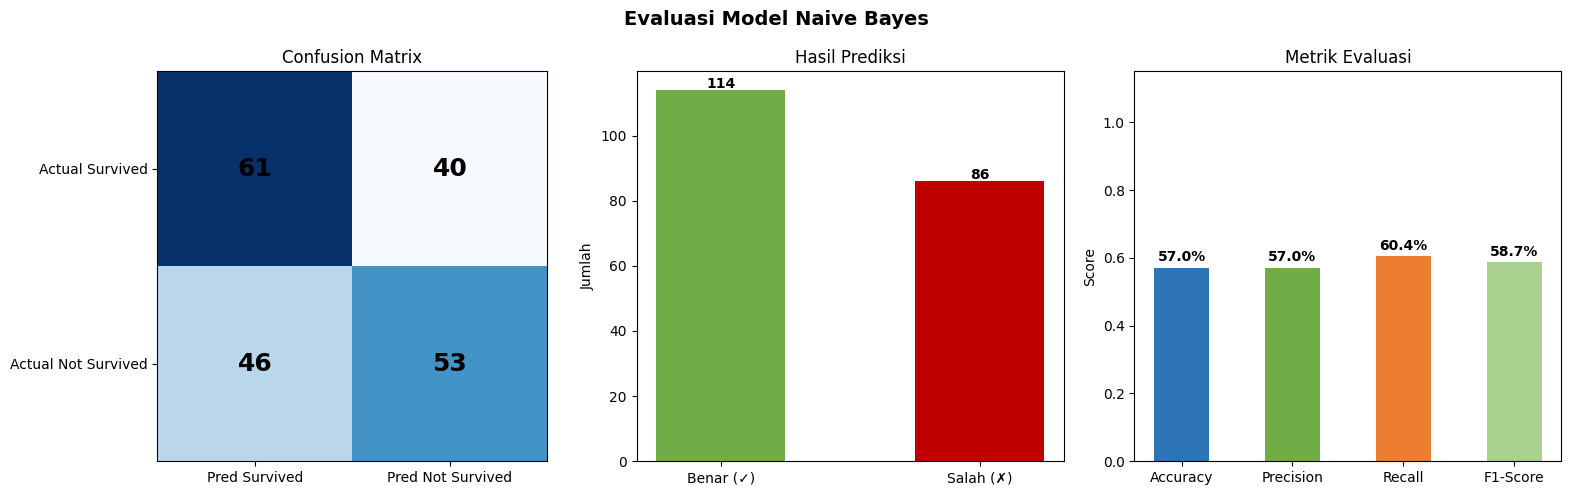

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluasi Model Naive Bayes', fontsize=14, fontweight='bold')

# ── Confusion Matrix heatmap ─────────────────────────────────────────────
cm = np.array([[TP, FN], [FP, TN]])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Survived','Pred Not Survived'])
axes[0].set_yticklabels(['Actual Survived','Actual Not Survived'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=18, fontweight='bold',
                     color='black' if cm[i,j] > cm.max()/2 else 'white')
axes[0].set_title('Confusion Matrix')

# ── Bar chart benar vs salah ─────────────────────────────────────────────
axes[1].bar(['Benar (✓)', 'Salah (✗)'], [correct, n_total-correct],
            color=['#70AD47','#C00000'], width=0.5)
axes[1].set_title('Hasil Prediksi')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate([correct, n_total-correct]):
    axes[1].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# ── Metrik bar ───────────────────────────────────────────────────────────
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values   = [accuracy, precision, recall, f1]
bar_cols = ['#2E75B6','#70AD47','#ED7D31','#A9D18E']
bars = axes[2].bar(metrics, values, color=bar_cols, width=0.5)
axes[2].set_ylim(0, 1.15)
axes[2].set_title('Metrik Evaluasi')
axes[2].set_ylabel('Score')
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 9. Kesimpulan

| Item | Nilai |
|---|---|
| Total Data | 200 |
| Metode | Naive Bayes + Laplace Smoothing |
| Fitur | Gender, Age (kategori), Speed (kategori), Helmet, Seatbelt |
| Akurasi | lihat output cell di atas |

**Interpretasi:**
- Model Naive Bayes berhasil mengklasifikasikan data kecelakaan ke kelas `Survived` dan `Not Survived`.
- Laplace Smoothing mencegah probabilitas bernilai nol untuk kombinasi fitur yang jarang muncul.
- Fitur seperti `Speed_of_Impact`, `Helmet_Used`, dan `Seatbelt_Used` memiliki pengaruh logis terhadap kemungkinan selamat.

**Catatan Diskritisasi:**
- `Age` dibagi menjadi 4 kategori: Young (≤30), Middle (31-45), Senior (46-60), Old (>60)
- `Speed_of_Impact` dibagi menjadi 3 kategori: Low (≤50), Medium (51-80), High (>80 km/h)

In [16]:
# Simpan hasil prediksi ke CSV
export_cols = ['Age','Gender','Speed_of_Impact','Age_Cat','Speed_Cat',
               'Helmet_Used','Seatbelt_Used','Survived','Predicted','Correct',
               'P_Survived','P_NotSurvived']
df[export_cols].to_csv('hasil_naive_bayes.csv', index=False)
print("✅ Hasil prediksi disimpan ke: hasil_naive_bayes.csv")

✅ Hasil prediksi disimpan ke: hasil_naive_bayes.csv
